In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.ndimage import rotate
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# TensorFlow & Keras for CNN Feature Extraction
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.datasets import mnist

# The Three Boosting Giants
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Extracting CNN features via MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step
Extracting CNN features via MobileNetV2...
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step

--- Training on Baseline (0 degrees rotation) ---
Training XGBoost on Flat Raw Pixels...


/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:01:56] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Baseline Accuracy: 0.9335
Training LightGBM on Flat Raw Pixels...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017822 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 86799
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 560
[LightGBM] [Info] Start training from score -2.301586
[LightGBM] [Info] Start training from score -2.183026
[LightGBM] [Info] Start training from score -2.311626
[LightGBM] [Info] Start training from score -2.271086
[LightGBM] [Info] Start training from score -2.322788
[LightGBM] [Info] Start training from score -2.449926
[LightGBM] [Info] Start training from score -2.288682
[LightGBM] [Info] Start training from score -2.234926
[LightGBM] [Info] Start training from score -2.360214
[LightGBM] [Info] Start training from score -2.324831
[LightGBM] [Warning] No further

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Baseline Accuracy: 0.9445
Training CatBoost on Flat Raw Pixels...
CatBoost Baseline Accuracy: 0.9380

--- Testing rotation: 45 degrees ---
Applying geometric rotation: 45 degrees...
XGBoost | 45deg Accuracy: 0.3720 (Drop: 0.5615)
LightGBM | 45deg Accuracy: 0.3685 (Drop: 0.5760)
CatBoost | 45deg Accuracy: 0.3655 (Drop: 0.5725)

--- Testing rotation: 60 degrees ---
Applying geometric rotation: 60 degrees...
XGBoost | 60deg Accuracy: 0.2250 (Drop: 0.7085)
LightGBM | 60deg Accuracy: 0.2145 (Drop: 0.7300)
CatBoost | 60deg Accuracy: 0.2245 (Drop: 0.7135)

--- Testing rotation: 75 degrees ---
Applying geometric rotation: 75 degrees...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


XGBoost | 75deg Accuracy: 0.1680 (Drop: 0.7655)
LightGBM | 75deg Accuracy: 0.1630 (Drop: 0.7815)
CatBoost | 75deg Accuracy: 0.1695 (Drop: 0.7685)

--- Testing rotation: 90 degrees ---
Applying geometric rotation: 90 degrees...
XGBoost | 90deg Accuracy: 0.1410 (Drop: 0.7925)
LightGBM | 90deg Accuracy: 0.1385 (Drop: 0.8060)
CatBoost | 90deg Accuracy: 0.1385 (Drop: 0.7995)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


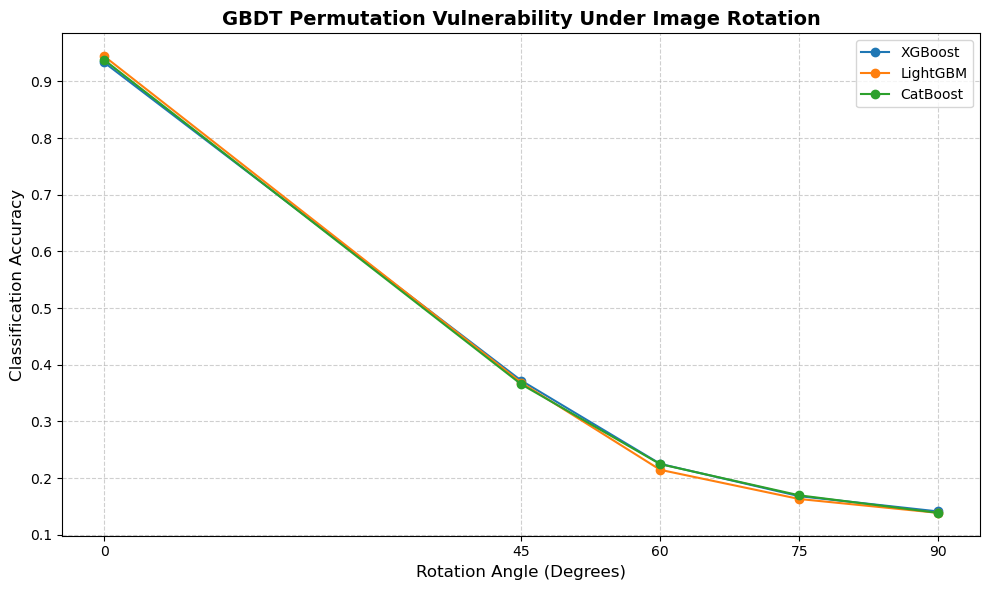

In [2]:


# ==========================================
# 1. DATA PREPARATION & FLATTENING
# ==========================================
def load_and_prepare_mnist(sample_size=10000):
    """Loads MNIST and returns flattened 1D arrays for standard GBDT ingestion."""
    print("Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    
    # Subsample for faster execution during the testing phase
    x_train, y_train = x_train[:sample_size], y_train[:sample_size]
    x_test, y_test = x_test[:sample_size//5], y_test[:sample_size//5]
    
    # Flatten images from 28x28 to 1D vectors of 784 features
    x_train_flat = x_train.reshape(x_train.shape[0], -1) / 255.0
    x_test_flat = x_test.reshape(x_test.shape[0], -1) / 255.0
    
    return x_train, y_train, x_test, y_test, x_train_flat, x_test_flat

# ==========================================
# 2. CNN FEATURE EXTRACTION (MobileNetV2)
# ==========================================
def extract_cnn_features(x_images):
    """Passes raw images through MobileNetV2 to extract spatial embeddings."""
    print("Extracting CNN features via MobileNetV2...")
    # MobileNetV2 expects 3-channel RGB images, typically 224x224. 
    # We must pad/resize the 28x28 grayscale MNIST images.
    x_rgb = np.stack((x_images,) * 3, axis=-1)
    x_resized = tf.image.resize(x_rgb, [96, 96]) # 96x96 is the min for MobileNetV2
    x_preprocessed = preprocess_input(x_resized)
    
    # Load pre-trained MobileNetV2 (without the top classification layer)
    feature_extractor = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(96, 96, 3))
    
    # Extract features (returns a dense vector for each image)
    embeddings = feature_extractor.predict(x_preprocessed, batch_size=64)
    return embeddings

# ==========================================
# 3. ROTATIONAL INVARIANCE STRESS TEST
# ==========================================
def generate_rotated_dataset(x_images, angle):
    """Rotates images by a specific angle to test spatial robustness."""
    print(f"Applying geometric rotation: {angle} degrees...")
    rotated_images = np.zeros_like(x_images)
    for i in range(len(x_images)):
        rotated_images[i] = rotate(x_images[i], angle, reshape=False, order=1)
    
    # Return flattened version for GBDTs
    return rotated_images, rotated_images.reshape(rotated_images.shape[0], -1) / 255.0

def run_image_crossover_experiment():
    # 1. Load Data
    x_train, y_train, x_test, y_test, X_train_flat, X_test_flat = load_and_prepare_mnist()
    
    # 2. Extract CNN Embeddings
    X_train_cnn = extract_cnn_features(x_train)
    X_test_cnn = extract_cnn_features(x_test)
    
    # 3. Initialize GBDT Models
    models = {
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(n_jobs=-1),
        'CatBoost': CatBoostClassifier(verbose=0, thread_count=-1)
    }
    
    results = {}
    
    # 4. Train and Test Baseline (0 degrees)
    print("\n--- Training on Baseline (0 degrees rotation) ---")
    for name, model in models.items():
        print(f"Training {name} on Flat Raw Pixels...")
        model.fit(X_train_flat, y_train)
        preds = model.predict(X_test_flat)
        base_acc = accuracy_score(y_test, preds)
        results[name] = {'Base_Accuracy': base_acc, 'Rotations': {}}
        print(f"{name} Baseline Accuracy: {base_acc:.4f}")
    
    # 5. Execute Rotational Stress Test
    angles = [45, 60, 75, 90]
    
    for angle in angles:
        print(f"\n--- Testing rotation: {angle} degrees ---")
        _, x_test_rotated_flat = generate_rotated_dataset(x_test, angle)
        
        for name, model in models.items():
            # Test the flat tabular model on the newly rotated coordinate features
            preds_rotated = model.predict(x_test_rotated_flat)
            rot_acc = accuracy_score(y_test, preds_rotated)
            results[name]['Rotations'][angle] = rot_acc
            print(f"{name} | {angle}deg Accuracy: {rot_acc:.4f} (Drop: {results[name]['Base_Accuracy'] - rot_acc:.4f})")
            
    # 6. Summary Plotting
    plot_rotational_degradation(results, angles)

def plot_rotational_degradation(results, angles):
    """Plots the accuracy degradation curve under geometric shifts."""
    plt.figure(figsize=(10, 6))
    
    for name, data in results.items():
        accuracies = [data['Base_Accuracy']] + [data['Rotations'][a] for a in angles]
        x_labels = [0] + angles
        plt.plot(x_labels, accuracies, marker='o', label=name)
        
    plt.title('GBDT Permutation Vulnerability Under Image Rotation', fontsize=14, fontweight='bold')
    plt.xlabel('Rotation Angle (Degrees)', fontsize=12)
    plt.ylabel('Classification Accuracy', fontsize=12)
    plt.xticks(x_labels)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig('GBDT_Rotational_Invariance_Test.pdf')
    plt.show()

if __name__ == "__main__":
    run_image_crossover_experiment()

Loading MNIST and creating canvases...

--- Training CNN Baseline ---
Epoch 1/15


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.3541 - loss: 1.7665 - val_accuracy: 0.5860 - val_loss: 1.1499
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7140 - loss: 0.9217 - val_accuracy: 0.8290 - val_loss: 0.6103
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.8374 - loss: 0.5506 - val_accuracy: 0.8900 - val_loss: 0.3863
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.8767 - loss: 0.4104 - val_accuracy: 0.8990 - val_loss: 0.3611
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8962 - loss: 0.3446 - val_accuracy: 0.9060 - val_loss: 0.2910
Epoch 6/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9078 - loss: 0.3038 - val_accuracy: 0.9060 - val_loss: 0.2865
Epoch 7/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9209 - loss: 0.2692 - val_accuracy: 0.9270 - val_loss: 0.2308
Epoch 8/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9301 - loss: 0.2386 - val_accuracy: 0.928

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:21:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training CatBoost...

FINAL PERFORMANCE: CENTERED VS SHIFTED
CNN        | Centered: 0.9435 | Shifted: 0.9390 | Absolute Drop: -0.0045
XGBoost    | Centered: 0.9335 | Shifted: 0.1270 | Absolute Drop: -0.8065
LightGBM   | Centered: 0.9445 | Shifted: 0.1310 | Absolute Drop: -0.8135
CatBoost   | Centered: 0.9310 | Shifted: 0.1450 | Absolute Drop: -0.7860


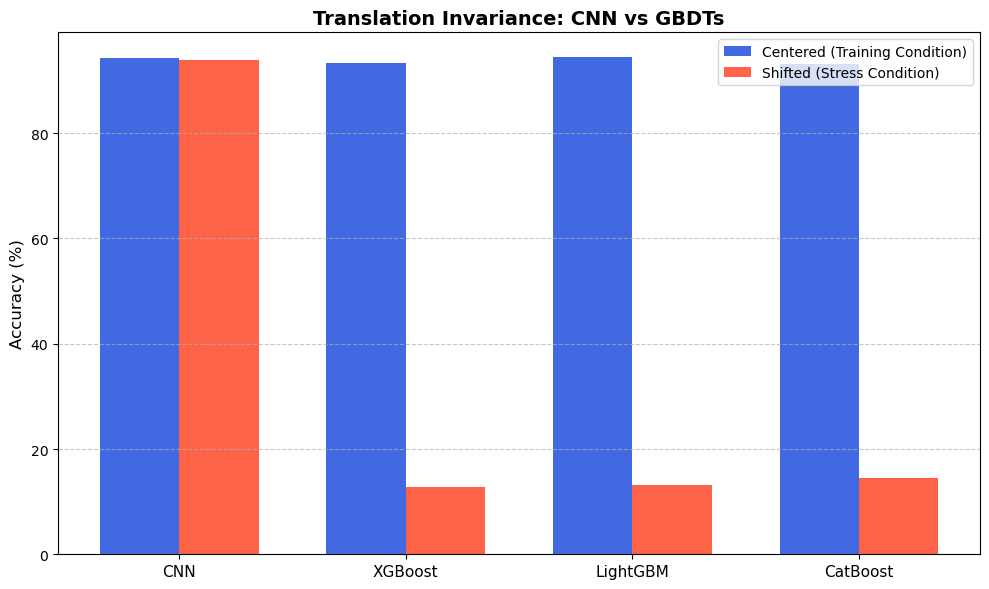

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ==========================================
# 1. DATA INGESTION & SHIFTING (from cnn_baseline)
# ==========================================
def create_shifted_dataset(images, canvas_size=64, random_shift=True):
    """Places 28x28 images onto a larger canvas, either centered or randomly shifted."""
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28 + 1)
            v_off = np.random.randint(0, canvas_size - 28 + 1)
        else:
            h_off, v_off = (canvas_size-28)//2, (canvas_size-28)//2 # Centered

        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
    return dataset

def load_and_prepare_canvas_data(sample_size=10000):
    print("Loading MNIST and creating canvases...")
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    
    # Subsample for execution speed
    x_train, y_train = x_train[:sample_size], y_train[:sample_size]
    x_test, y_test = x_test[:sample_size//5], y_test[:sample_size//5]
    
    x_train, x_test = x_train / 255.0, x_test / 255.0  

    # Create Centered Training Data
    X_train_centered = create_shifted_dataset(x_train, random_shift=False)
    X_test_centered = create_shifted_dataset(x_test, random_shift=False)
    
    # Create Randomly Shifted Test Data (Stress Test)
    X_test_shifted = create_shifted_dataset(x_test, random_shift=True)
    
    return X_train_centered, X_test_centered, X_test_shifted, y_train, y_test

# ==========================================
# 2. CNN ARCHITECTURE (from cnn_baseline)
# ==========================================
def make_conv_model():
    model = Sequential()
    
    # Block 1: Basic edge detection
    model.add(Conv2D(filters=32, kernel_size=(3,3), padding='Same', activation='relu', input_shape=(64,64,1)))
    model.add(MaxPool2D(pool_size=(2,2)))
    
    # Block 2: Complex shape detection (Increase filters to 64)
    model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
    model.add(MaxPool2D(pool_size=(2,2)))
    
    # Block 3: High-level features (Increase filters to 128)
    model.add(Conv2D(filters=128, kernel_size=(3,3), padding='Same', activation='relu'))
    
    # Now, Global Average Pooling will compress the image into 128 distinct numbers,
    # giving the Dense layer plenty of information to make a highly accurate decision.
    model.add(GlobalAveragePooling2D()) 
    
    model.add(Dense(10, activation="softmax"))
    
    model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# ==========================================
# 3. EXECUTION FLOW
# ==========================================
def run_crossover_analysis():
    # 1. Prepare Data
    X_train_centered, X_test_centered, X_test_shifted, y_train, y_test = load_and_prepare_canvas_data()
    
    # Reshape for CNN (Samples, 64, 64, 1)
    X_train_cnn = X_train_centered.reshape(-1, 64, 64, 1)
    X_test_cnn_centered = X_test_centered.reshape(-1, 64, 64, 1)
    X_test_cnn_shifted = X_test_shifted.reshape(-1, 64, 64, 1)
    
    # Reshape for GBDTs (Samples, 4096 tabular features)
    X_train_flat = X_train_centered.reshape(-1, 64*64)
    X_test_flat_centered = X_test_centered.reshape(-1, 64*64)
    X_test_flat_shifted = X_test_shifted.reshape(-1, 64*64)

    # 2. Train and Evaluate CNN
    print("\n--- Training CNN Baseline ---")
    cnn_model = make_conv_model()
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    cnn_model.fit(X_train_cnn, y_train, epochs=15, validation_split=0.1, callbacks=[early_stop], verbose=1)
    
    _, cnn_base_acc = cnn_model.evaluate(X_test_cnn_centered, y_test, verbose=0)
    _, cnn_shift_acc = cnn_model.evaluate(X_test_cnn_shifted, y_test, verbose=0)
    
    # 3. Train and Evaluate GBDTs
    print("\n--- Training GBDT Baselines (Tabular Representation) ---")
    models = {
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(verbose=0, thread_count=-1)
    }
    
    results = {'CNN': {'Centered': cnn_base_acc, 'Shifted': cnn_shift_acc}}
    
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train_flat, y_train)
        
        acc_base = accuracy_score(y_test, model.predict(X_test_flat_centered))
        acc_shift = accuracy_score(y_test, model.predict(X_test_flat_shifted))
        
        results[name] = {'Centered': acc_base, 'Shifted': acc_shift}
        
    # 4. Report and Plot
    print("\n" + "="*40)
    print("FINAL PERFORMANCE: CENTERED VS SHIFTED")
    print("="*40)
    for name, res in results.items():
        drop = res['Centered'] - res['Shifted']
        print(f"{name:10} | Centered: {res['Centered']:.4f} | Shifted: {res['Shifted']:.4f} | Absolute Drop: -{drop:.4f}")
        
    plot_results(results)

def plot_results(results):
    models = list(results.keys())
    base_acc = [results[m]['Centered'] * 100 for m in models]
    shift_acc = [results[m]['Shifted'] * 100 for m in models]
    
    x = np.arange(len(models))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, base_acc, width, label='Centered (Training Condition)', color='royalblue')
    ax.bar(x + width/2, shift_acc, width, label='Shifted (Stress Condition)', color='tomato')
    
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Translation Invariance: CNN vs GBDTs', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=11)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_crossover_analysis()

Loading MNIST and generating stress conditions...

--- Training CNN Baseline ---
Epoch 1/15


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4056 - loss: 1.6886 - val_accuracy: 0.7420 - val_loss: 0.9197
Epoch 2/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8088 - loss: 0.6703 - val_accuracy: 0.8460 - val_loss: 0.4747
Epoch 3/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8794 - loss: 0.4181 - val_accuracy: 0.9090 - val_loss: 0.3154
Epoch 4/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9031 - loss: 0.3263 - val_accuracy: 0.9240 - val_loss: 0.2714
Epoch 5/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9192 - loss: 0.2741 - val_accuracy: 0.9350 - val_loss: 0.2602
Epoch 6/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9296 - loss: 0.2371 - val_accuracy: 0.9360 - val_loss: 0.2351
Epoch 7/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9363 - loss: 0.2115 - val_accuracy: 0.9400 - val_loss: 0.1875
Epoch 8/15
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9411 - loss: 0.1982 - val_accuracy: 0.944

/opt/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [12:36:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training CatBoost...


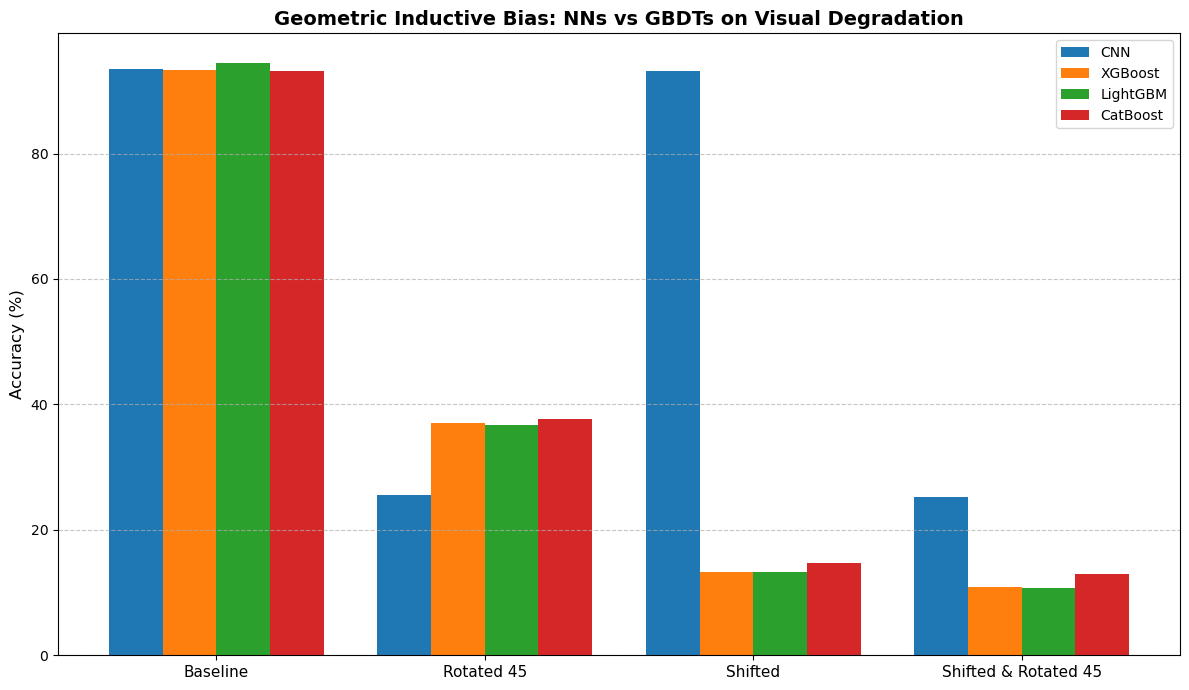

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ==========================================
# 1. UNIFIED SPATIAL STRESS GENERATOR
# ==========================================
def create_stress_dataset(images, canvas_size=56, random_shift=False, angle=0):
    """
    Applies geometric distortions (rotation and/or translation) to the images 
    and places them onto a unified canvas.
    """
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    
    for i, img in enumerate(images):
        # 1. Apply Rotation
        if angle != 0:
            # reshape=False keeps the bounding box 28x28 to fit our canvas logic
            processed_img = rotate(img, angle, reshape=False, order=1)
        else:
            processed_img = img
            
        # 2. Apply Translation (Shifting)
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28 + 1)
            v_off = np.random.randint(0, canvas_size - 28 + 1)
        else:
            h_off, v_off = (canvas_size - 28) // 2, (canvas_size - 28) // 2 # Centered

        dataset[i, v_off:v_off+28, h_off:h_off+28] = processed_img
        
    return dataset

def load_and_prepare_data(sample_size=10000, canvas_size=56):
    print("Loading MNIST and generating stress conditions...")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    
    # Subsample for execution speed
    x_train, y_train = x_train[:sample_size], y_train[:sample_size]
    x_test, y_test = x_test[:sample_size//5], y_test[:sample_size//5]
    x_train, x_test = x_train / 255.0, x_test / 255.0  

    # Training Data (Clean, Centered, Upright)
    X_train_base = create_stress_dataset(x_train, canvas_size, random_shift=False, angle=0)
    
    # Testing Conditions (The Stress Matrix)
    test_conditions = {
        'Baseline': create_stress_dataset(x_test, canvas_size, random_shift=False, angle=0),
        'Rotated_45': create_stress_dataset(x_test, canvas_size, random_shift=False, angle=45),
        'Shifted': create_stress_dataset(x_test, canvas_size, random_shift=True, angle=0),
        'Shifted_&_Rotated_45': create_stress_dataset(x_test, canvas_size, random_shift=True, angle=45)
    }
    
    return X_train_base, test_conditions, y_train, y_test, canvas_size

# ==========================================
# 2. ROBUST CNN ARCHITECTURE
# ==========================================
def make_robust_cnn(input_shape):
    """CNN with increasing filters and GAP for high capacity and translation invariance."""
    model = Sequential([
        Conv2D(32, (3,3), padding='Same', activation='relu', input_shape=input_shape),
        MaxPool2D((2,2)),
        Conv2D(64, (3,3), padding='Same', activation='relu'),
        MaxPool2D((2,2)),
        Conv2D(128, (3,3), padding='Same', activation='relu'),
        GlobalAveragePooling2D(), # The key to spatial invariance
        Dense(10, activation="softmax")
    ])
    model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# ==========================================
# 3. EXECUTION AND COMPARISON FLOW
# ==========================================
def run_unified_analysis():
    X_train_base, test_conds, y_train, y_test, canvas = load_and_prepare_data()
    flat_dim = canvas * canvas
    
    # --- A. Train Deep Learning (CNN) ---
    print("\n--- Training CNN Baseline ---")
    cnn_model = make_robust_cnn(input_shape=(canvas, canvas, 1))
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    cnn_model.fit(X_train_base.reshape(-1, canvas, canvas, 1), y_train, 
                  epochs=15, validation_split=0.1, callbacks=[early_stop], verbose=1)
    
    results = {'CNN': {}}
    for cond_name, X_test in test_conds.items():
        _, acc = cnn_model.evaluate(X_test.reshape(-1, canvas, canvas, 1), y_test, verbose=0)
        results['CNN'][cond_name] = acc

    # --- B. Train Tabular GBDTs ---
    print("\n--- Training GBDT Baselines (Tabular Representation) ---")
    X_train_flat = X_train_base.reshape(-1, flat_dim)
    
    models = {
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
        'LightGBM': lgb.LGBMClassifier(n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(verbose=0, thread_count=-1)
    }
    
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(X_train_flat, y_train)
        results[name] = {}
        for cond_name, X_test in test_conds.items():
            acc = accuracy_score(y_test, model.predict(X_test.reshape(-1, flat_dim)))
            results[name][cond_name] = acc

    plot_unified_results(results, test_conds.keys())

def plot_unified_results(results, conditions):
    models = list(results.keys())
    x = np.arange(len(conditions))
    width = 0.2
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, model in enumerate(models):
        scores = [results[model][cond] * 100 for cond in conditions]
        ax.bar(x + (i - 1.5) * width, scores, width, label=model, color=colors[i])
        
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Geometric Inductive Bias: NNs vs GBDTs on Visual Degradation', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace('_', ' ') for c in conditions], fontsize=11)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('Unified_Geometric_Stress_Test.pdf')
    plt.show()

if __name__ == "__main__":
    run_unified_analysis()